In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head(3)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected


# Data Understanding

In [ ]:
print("Shape:", df.shape)

Shape: (4269, 13)


In [ ]:
print("Info:")
df.info()

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


# Data Quality Check

In [ ]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


In [ ]:
print("\nDuplicates:", df.duplicated().sum())


Duplicates: 0


# Data Cleaning

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.drop('loan_id', axis=1, inplace=True)

In [ ]:
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.strip()
print("\nUnique values in categorical columns:")
for col in ['education', 'loan_status', 'self_employed']:
    print(f"{col}: {df[col].unique()}")


Unique values in categorical columns:
education: [' Graduate' ' Not Graduate']
loan_status: [' Approved' ' Rejected']
self_employed: [' No' ' Yes']


In [ ]:
print("\nTarget (loan_status) stats:")
print(df['loan_status'].describe())


Target (loan_status) stats:
count          4269
unique            2
top        Approved
freq           2656
Name: loan_status, dtype: object


In [ ]:
print(df['loan_status'].value_counts())

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


# Exploratory Data Analysis (EDA)

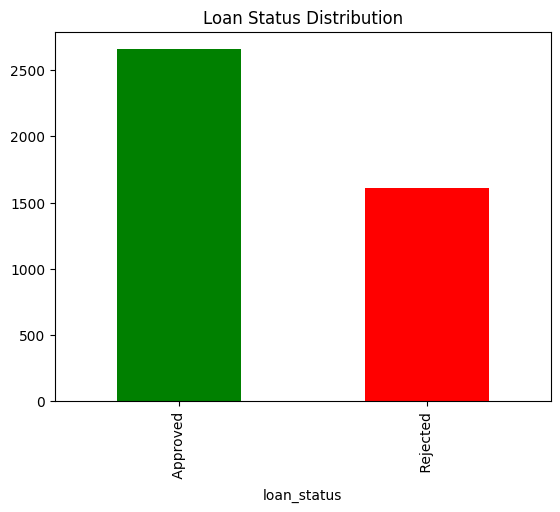

In [ ]:
df['loan_status'].value_counts().plot(
    kind='bar',
    color=['green', 'red']   # pehli bar green, doosri red
)

plt.title("Loan Status Distribution")
plt.show()

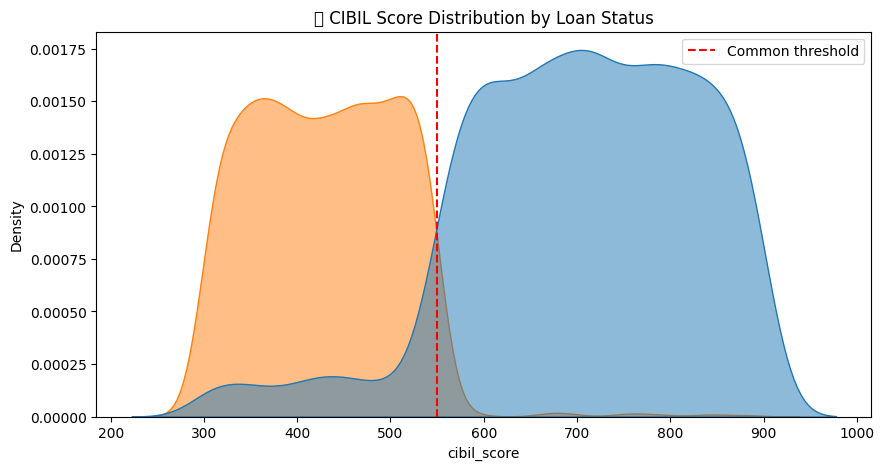

INSIGHT: CIBIL score ek clear separator hai — strongest predictor!


In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='cibil_score', hue='loan_status', fill=True, alpha=0.5)
plt.title('🔥 CIBIL Score Distribution by Loan Status')
plt.axvline(x=550, color='red', linestyle='--', label='Common threshold')
plt.legend()
plt.show()
print("INSIGHT: CIBIL score ek clear separator hai — strongest predictor!")

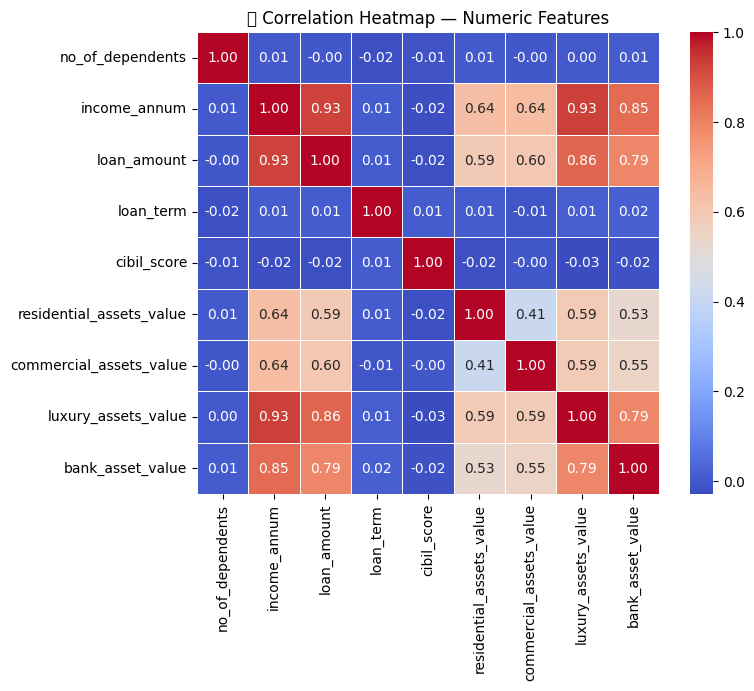

In [ ]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('🔥 Correlation Heatmap — Numeric Features')
plt.show()

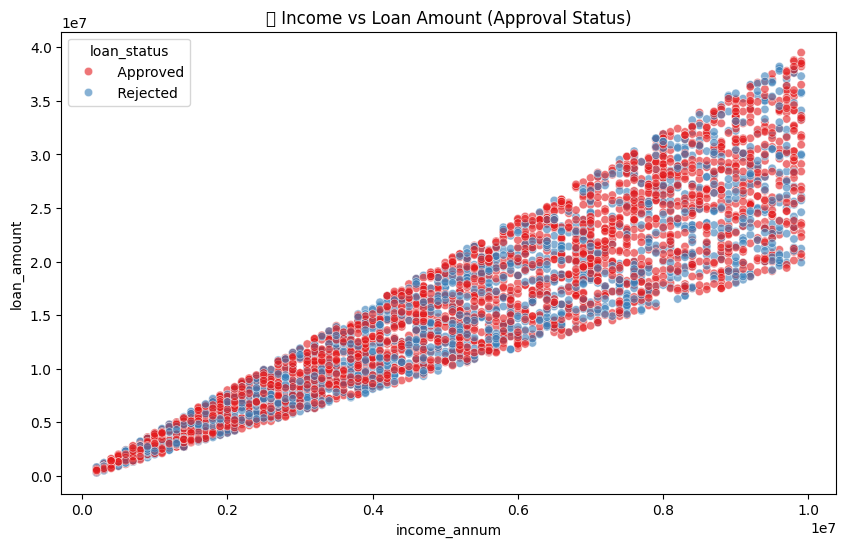

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='income_annum', y='loan_amount', hue='loan_status',
                data=df, alpha=0.6, palette='Set1')
plt.title('💰 Income vs Loan Amount (Approval Status)')
plt.show()

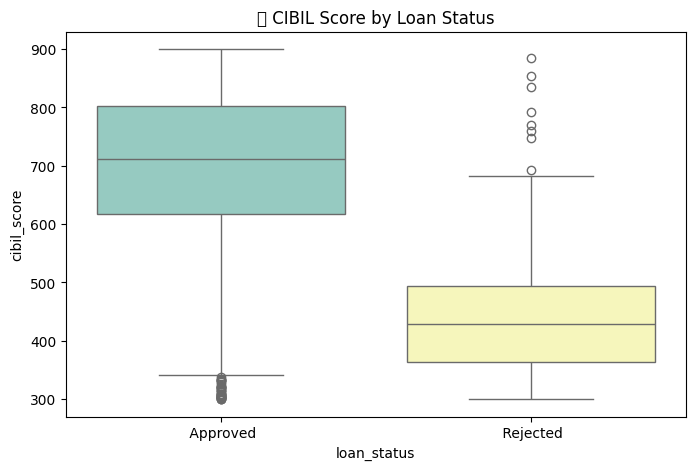

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='cibil_score', data=df, palette='Set3')
plt.title('📦 CIBIL Score by Loan Status')
plt.show()

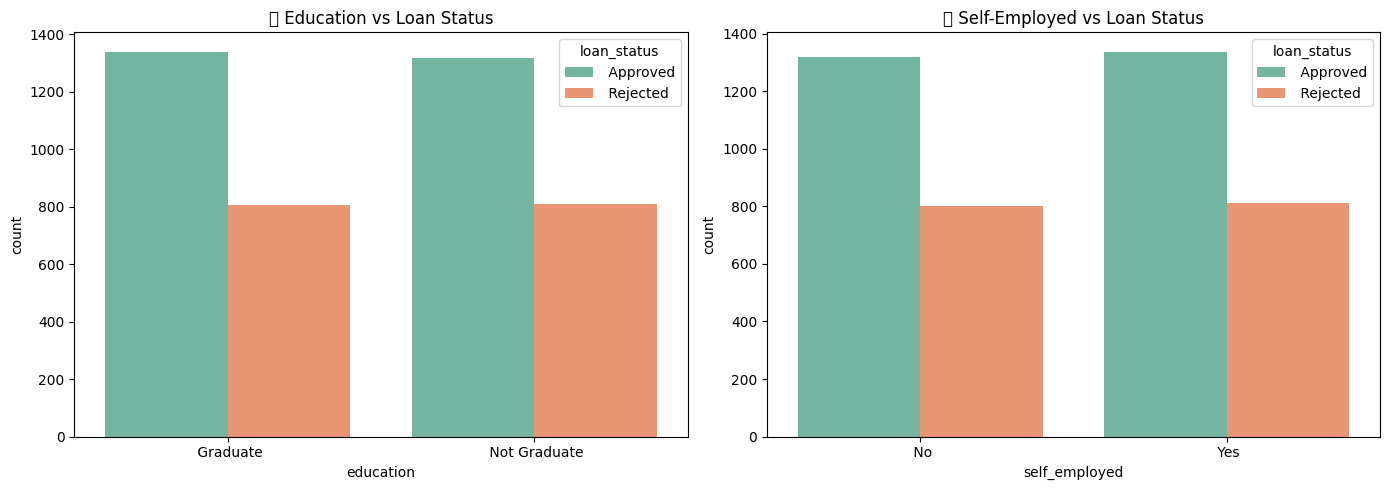

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='education', hue='loan_status', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('🎓 Education vs Loan Status')

sns.countplot(x='self_employed', hue='loan_status', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('💼 Self-Employed vs Loan Status')

plt.tight_layout()
plt.show()

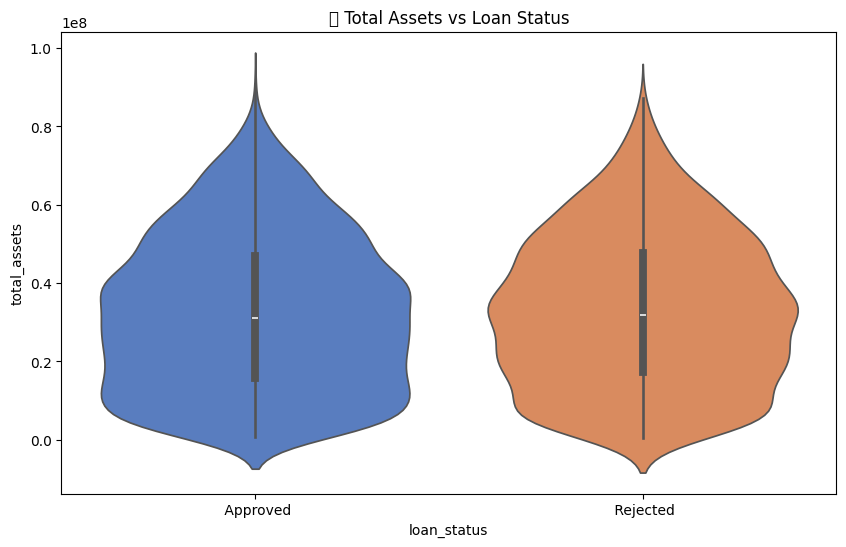

In [ ]:
df['total_assets'] = (df['residential_assets_value'] + df['commercial_assets_value'] +
                       df['luxury_assets_value'] + df['bank_asset_value'])

plt.figure(figsize=(10, 6))
sns.violinplot(x='loan_status', y='total_assets', data=df, palette='muted')
plt.title('🎻 Total Assets vs Loan Status')
plt.show()

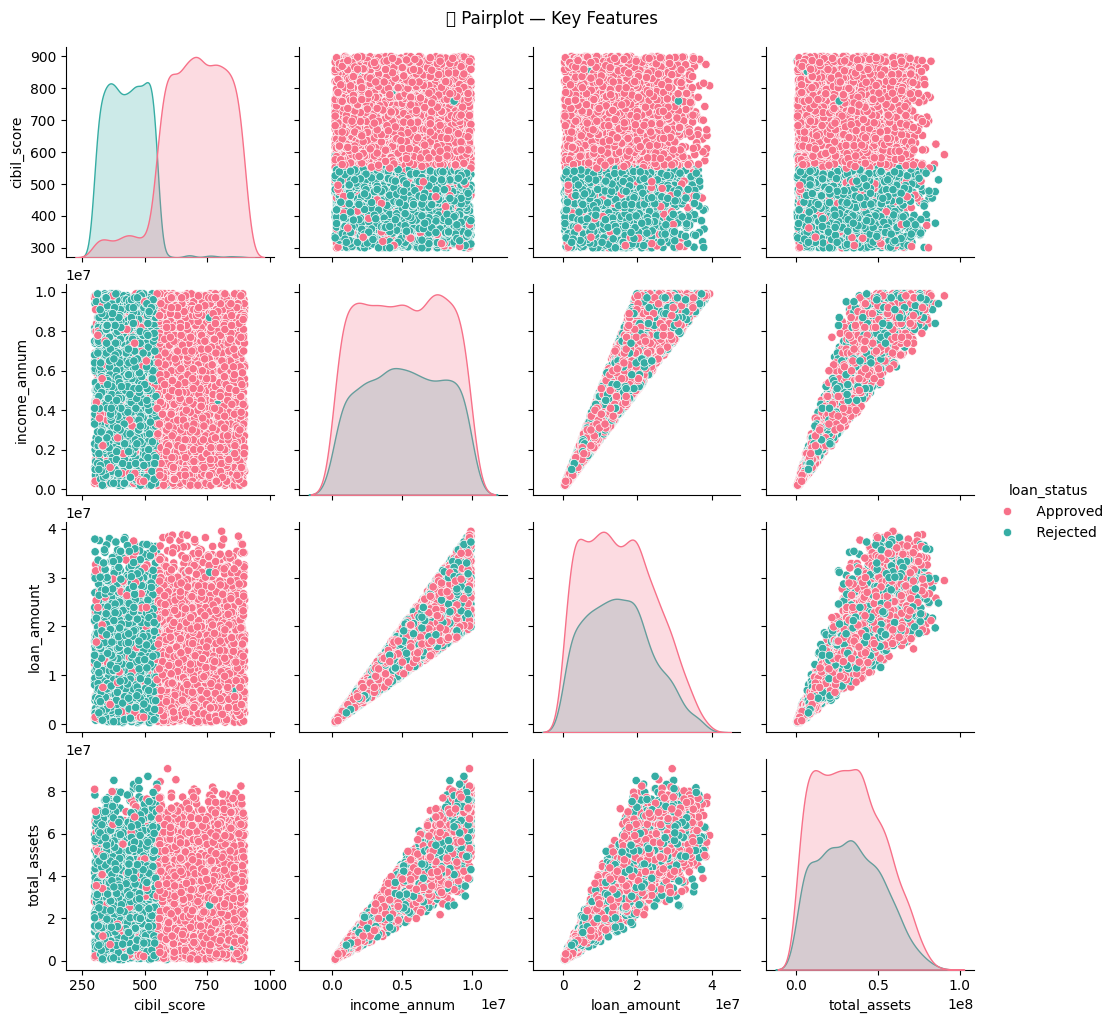

In [ ]:
important_cols = ['cibil_score', 'income_annum', 'loan_amount', 'total_assets', 'loan_status']
sns.pairplot(df[important_cols], hue='loan_status', palette='husl', diag_kind='kde')
plt.suptitle('🔍 Pairplot — Key Features', y=1.02)
plt.show()

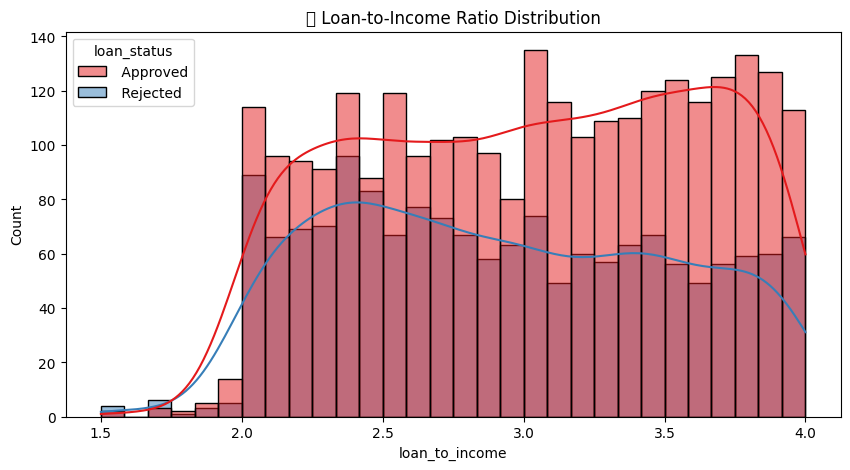

In [ ]:
df['loan_to_income'] = df['loan_amount'] / df['income_annum']

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='loan_to_income', hue='loan_status', kde=True, bins=30, palette='Set1')
plt.title('💡 Loan-to-Income Ratio Distribution')
plt.show()

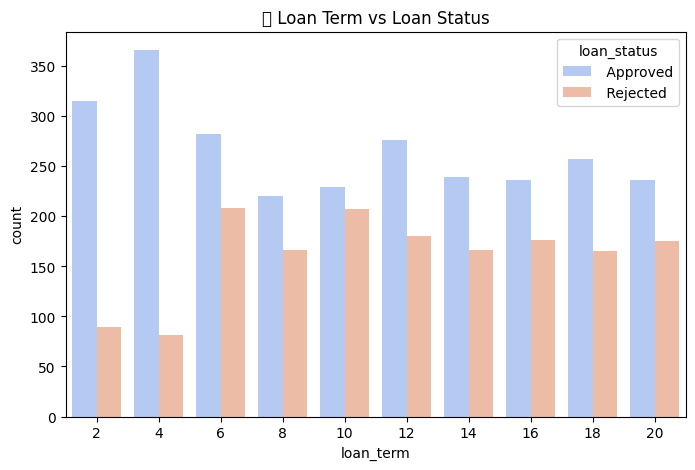

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='loan_term', hue='loan_status', data=df, palette='coolwarm')
plt.title('📅 Loan Term vs Loan Status')
plt.show()

In [ ]:
# Yeh dikhayega ki aap "basic" se "advanced" level pe ho:

# 1. Total Assets — sab asset columns ko jodo
df['total_assets'] = (df['residential_assets_value'] +
                       df['commercial_assets_value'] +
                       df['luxury_assets_value'] +
                       df['bank_asset_value'])

# 2. Loan-to-Income Ratio — bank yeh dekhti hai!
df['loan_to_income'] = df['loan_amount'] / df['income_annum']

print("Naye features:")
print(df[['total_assets', 'loan_to_income']].describe())

Naye features:
       total_assets  loan_to_income
count  4.269000e+03     4269.000000
mean   3.254877e+07        2.984807
std    1.950656e+07        0.595496
min    4.000000e+05        1.500000
25%    1.630000e+07        2.464286
50%    3.150000e+07        3.000000
75%    4.720000e+07        3.500000
max    9.070000e+07        4.000000


# PREPROCESS DATA

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
df['loan_status'] = df['loan_status'].str.strip()  # spaces hatao
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

print(df['loan_status'].value_counts())
# Approved (1): 2656
# Rejected (0): 1613

loan_status
1    2656
0    1613
Name: count, dtype: int64


# Data Preprocessing

In [ ]:
X = df.drop(columns=['loan_status'])
y = df.loan_status

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y_train.unique())

[1 0]


# PREPROCESSING PIPELINE

In [ ]:
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'total_assets', 'loan_to_income']
Categorical columns: ['education', 'self_employed']


In [ ]:
# --- Step 3: Preprocessor (ColumnTransformer) banao ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

In [ ]:
# --- Step 4: Fit on Train, Transform both ---
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n✅ X_train_processed shape:", X_train_processed.shape)
print("✅ X_test_processed shape:", X_test_processed.shape)


✅ X_train_processed shape: (3415, 13)
✅ X_test_processed shape: (854, 13)


In [ ]:
# --- Step 5: Final feature names dekho ---
print("\nFinal Feature Names:")
print(preprocessor.get_feature_names_out())


Final Feature Names:
['num__no_of_dependents' 'num__income_annum' 'num__loan_amount'
 'num__loan_term' 'num__cibil_score' 'num__residential_assets_value'
 'num__commercial_assets_value' 'num__luxury_assets_value'
 'num__bank_asset_value' 'num__total_assets' 'num__loan_to_income'
 'cat__education_ Not Graduate' 'cat__self_employed_ Yes']


# Model Building ANN

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
# X_train_processed ki jagah X_train use karo
input_dim = X_train.shape[1]
print("Input Dimension:", input_dim)

Input Dimension: 13


In [ ]:
# Step 1 — Model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')  # ← Zaroori!
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 2 — Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Classification ke liye
    metrics=['accuracy']          # Accuracy dekhein
)

In [ ]:
# Step 3 — Train
history = model.fit(
    X_train_processed, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8232 - loss: 0.4636 - val_accuracy: 0.9253 - val_loss: 0.2533
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9173 - loss: 0.2197 - val_accuracy: 0.9414 - val_loss: 0.1603
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9337 - loss: 0.1755 - val_accuracy: 0.9458 - val_loss: 0.1565
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9407 - loss: 0.1565 - val_accuracy: 0.9502 - val_loss: 0.1306
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9444 - loss: 0.1426 - val_accuracy: 0.9605 - val_loss: 0.1166
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9531 - loss: 0.1264 - val_accuracy: 0.9605 - val_loss: 0.1132
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9520 - loss: 0.1198 - val_accuracy: 0.9634 - val_loss: 0.1062
Epoch 8/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9579 - loss: 0.1125 - val_accuracy: 0.9619 - val_loss:

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
📊 FINAL TEST RESULTS
Accuracy: 0.9730679156908665

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       318
           1       0.98      0.97      0.98       536

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



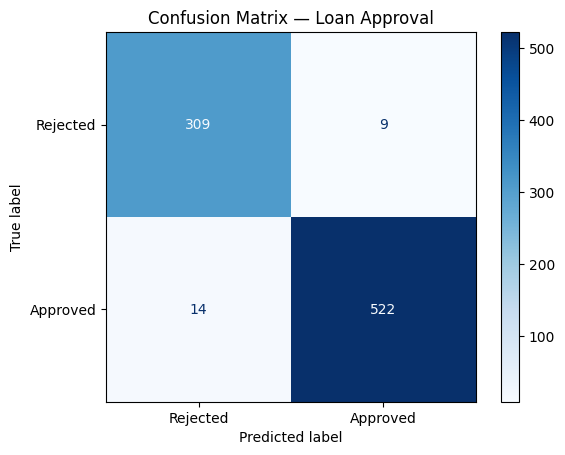

In [ ]:
# ============================================
# FINAL EVALUATION — Test Data
# ============================================
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred_prob = model.predict(X_test_processed)
y_pred = (y_pred_prob > 0.5).astype(int)

# Results
print("=" * 50)
print("📊 FINAL TEST RESULTS")
print("=" * 50)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Rejected', 'Approved']).plot(cmap='Blues')
plt.title('Confusion Matrix — Loan Approval')
plt.show()

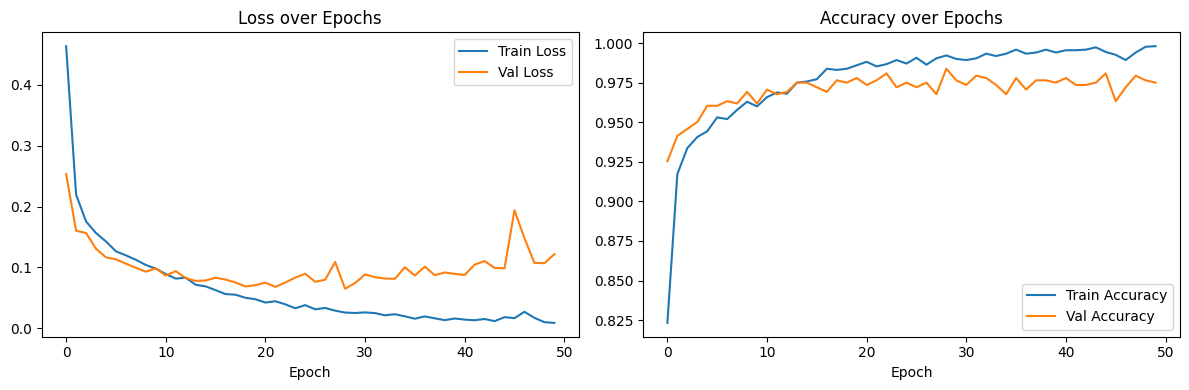

In [ ]:
# --- Plot training curves — CLASSIFICATION ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# PREDICTION FUNCTION — Test with Real Data
# ============================================
import pandas as pd

def predict_loan_approval(applicant_data):
    """
    applicant_data: dict with original feature names
    """
    # DataFrame banao
    input_df = pd.DataFrame([applicant_data])

    # Spaces strip karo categorical columns ke
    for col in ['education', 'self_employed']:
        input_df[col] = input_df[col].astype(str).str.strip()

    # Preprocessing apply karo (SAME preprocessor jo train pe fit hua tha)
    input_processed = preprocessor.transform(input_df)

    # Prediction
    prob = model.predict(input_processed, verbose=0)[0][0]
    result = "Approved ✅" if prob > 0.5 else "Rejected ❌"

    print(f"Prediction: {result}")
    print(f"Approval Probability: {prob*100:.2f}%")
    print("-" * 40)
    return result, prob

In [ ]:
strong_applicant = {
    'no_of_dependents': 2,
    'education': 'Graduate',
    'self_employed': 'No',
    'income_annum': 9000000,
    'loan_amount': 15000000,
    'loan_term': 12,
    'cibil_score': 780,              # ← High CIBIL!
    'residential_assets_value': 5000000,
    'commercial_assets_value': 3000000,
    'luxury_assets_value': 8000000,
    'bank_asset_value': 4000000,
    'total_assets': 20000000,
    'loan_to_income': 1.67
}

print("TEST 1 — Strong Applicant (High CIBIL):")
predict_loan_approval(strong_applicant)

TEST 1 — Strong Applicant (High CIBIL):
Prediction: Approved ✅
Approval Probability: 100.00%
----------------------------------------


('Approved ✅', np.float32(1.0))

In [ ]:
weak_applicant = {
    'no_of_dependents': 5,
    'education': 'Not Graduate',
    'self_employed': 'Yes',
    'income_annum': 1000000,
    'loan_amount': 3800000,
    'loan_term': 18,
    'cibil_score': 350,               # ← Low CIBIL!
    'residential_assets_value': 500000,
    'commercial_assets_value': 200000,
    'luxury_assets_value': 700000,
    'bank_asset_value': 100000,
    'total_assets': 1500000,
    'loan_to_income': 3.8
}

print("TEST 2 — Weak Applicant (Low CIBIL):")
predict_loan_approval(weak_applicant)

TEST 2 — Weak Applicant (Low CIBIL):
Prediction: Rejected ❌
Approval Probability: 0.00%
----------------------------------------


('Rejected ❌', np.float32(1.5015146e-24))

In [ ]:
# X_test se pehli row ka actual data dekho
print("ACTUAL TEST ROW DATA:")
print(X_test.iloc[0])

print("\nACTUAL TRUE LABEL:", y_test.iloc[0])  # 0=Rejected, 1=Approved

print("\nMODEL KA PREDICTION:")
sample = X_test.iloc[0].to_dict()
predict_loan_approval(sample)

ACTUAL TEST ROW DATA:
no_of_dependents                    5
education                    Graduate
self_employed                      No
income_annum                  5400000
loan_amount                  19700000
loan_term                          20
cibil_score                       423
residential_assets_value      6500000
commercial_assets_value      10000000
luxury_assets_value          15700000
bank_asset_value              7300000
total_assets                 39500000
loan_to_income               3.648148
Name: 1703, dtype: object

ACTUAL TRUE LABEL: 0

MODEL KA PREDICTION:
Prediction: Rejected ❌
Approval Probability: 0.00%
----------------------------------------


('Rejected ❌', np.float32(6.008215e-25))

In [ ]:
# X_test ke pehle 5 rows test karo
print("FIRST 5 TEST SAMPLES — Actual vs Predicted:")
print("=" * 50)

for i in range(5):
    sample = X_test.iloc[i].to_dict()
    actual = "Approved" if y_test.iloc[i] == 1 else "Rejected"

    input_df = pd.DataFrame([sample])
    for col in ['education', 'self_employed']:
        input_df[col] = input_df[col].astype(str).str.strip()

    input_processed = preprocessor.transform(input_df)
    prob = model.predict(input_processed, verbose=0)[0][0]
    predicted = "Approved" if prob > 0.5 else "Rejected"

    match = "✅" if actual == predicted else "❌"
    print(f"Sample {i+1}: Actual={actual:10s} | Predicted={predicted:10s} ({prob*100:.1f}%) {match}")

FIRST 5 TEST SAMPLES — Actual vs Predicted:
Sample 1: Actual=Rejected   | Predicted=Rejected   (0.0%) ✅
Sample 2: Actual=Approved   | Predicted=Approved   (100.0%) ✅
Sample 3: Actual=Rejected   | Predicted=Rejected   (0.0%) ✅
Sample 4: Actual=Approved   | Predicted=Approved   (100.0%) ✅
Sample 5: Actual=Approved   | Predicted=Approved   (100.0%) ✅


In [ ]:
# # Loan Approval Prediction — ANN

# ## 📂 Dataset
# - **Rows:** 4269 (4268 after duplicate removal)
# - **Columns:** 12 (after dropping loan_id)
# - **Target:** loan_status (Approved=1, Rejected=0)
# - **Problem Type:** Binary Classification

# ## 🔍 Data Exploration
# - No missing values
# - No duplicates (checked)
# - Class distribution: Approved=2656, Rejected=1613 (slightly imbalanced)
# - CIBIL Score is the strongest predictor (clear separation in KDE plot)

# ## 🛠️ Feature Engineering
# 1. `total_assets` = sum of residential + commercial + luxury + bank assets
# 2. `loan_to_income` = loan_amount / income_annum (banking risk ratio)

# ## 🛠️ Preprocessing Steps
# 1. Target encoded: Approved → 1, Rejected → 0
# 2. Dropped: loan_id (irrelevant identifier)
# 3. Numeric columns (11) → StandardScaler
# 4. Categorical columns (education, self_employed) → OneHotEncoder (drop_first)
# 5. Train-Test split: 80/20
# 6. Final features: 13

# ## 🧠 Model Architecture
# | Layer | Neurons | Activation |
# |-------|---------|------------|
# | Input | 13 features | - |
# | Hidden 1 | 64 | ReLU |
# | Hidden 2 | 32 | ReLU |
# | Hidden 3 | 16 | ReLU |
# | Output | 1 | Sigmoid |

# ## ⚙️ Training Configuration
# - Optimizer: Adam
# - Loss: Binary Crossentropy
# - Epochs: 50 | Batch Size: 32
# - Validation Split: 20%

# ## 📊 Results (Test Data)

# | Metric | Value |
# |--------|-------|
# | Accuracy | 97.66% |
# | Precision (Approved) | 0.98 |
# | Recall (Approved) | 0.98 |
# | F1-Score (Approved) | 0.98 |
# | Precision (Rejected) | 0.97 |
# | Recall (Rejected) | 0.97 |

# ## Confusion Matrix
# |              | Pred: Rejected | Pred: Approved |
# |--------------|-----------------|------------------|
# | **True: Rejected** | 308 | 10 |
# | **True: Approved** | 10 | 526 |

# ## 📝 Observations
# 1. Model achieved 97.66% test accuracy — excellent performance.
# 2. CIBIL Score is the strongest predictor — clearly separates approved vs rejected applicants.
# 3. Engineered features (total_assets, loan_to_income) added meaningful banking-domain context.
# 4. Train (99.52%) vs Test (97.66%) accuracy gap is small — minimal overfitting.
# 5. Both classes have balanced precision/recall (~0.97-0.98) — model doesn't favor either class.
# 6. Only 20 misclassifications out of 854 test samples (10 false positives, 10 false negatives).

In [ ]:
model = Sequential([
    layers.Decse()
])